# W2 D29 — DX/RX Final Model: Portfolio Arc Finale

**Domain:** MedPulse — Patient Appointment Conversion  
**Portfolio arc:** D15 (Logistic Regression baseline) → **D29 (XGBoost + SHAP upgrade)**

You built the DX/RX conversion model on Day 15 using logistic regression. Today you revisit the same business problem, same data generating process — but now with the full toolkit. You'll upgrade to XGBoost, explain every prediction with SHAP, calibrate probabilities for revenue forecasting, and present a business-ready summary.

**Questions:**
1. Rebuild and compare the D15 baseline vs today's XGBoost challenger
2. SHAP global explanation — what drives appointment conversions?
3. SHAP local explanation — explain two individual predictions
4. Calibrate the XGBoost model and build a revenue impact curve
5. Write the executive summary cell


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(420)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, roc_curve,
                             precision_recall_curve, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
import shap

np.random.seed(420)
print('Libraries loaded — D29 DX/RX Final Model')

Libraries loaded — D29 DX/RX Final Model


## Dataset — MedPulse Patient Sessions (same DGP as D15)

Same synthetic population, same seed. This ensures a fair head-to-head comparison with Day 15.

In [29]:
np.random.seed(420)
n = 8000  # larger dataset — more data, better models

age               = np.random.normal(42, 14, n).clip(18, 80)
session_depth     = np.random.randint(1, 12, n).astype(float)
time_on_site      = np.random.exponential(4, n).clip(0.1, 30)
articles_read     = np.random.poisson(2.5, n).astype(float)
is_mobile         = np.random.binomial(1, 0.55, n).astype(float)
health_content    = np.random.binomial(1, 0.40, n).astype(float)
prior_bookings    = np.random.poisson(0.8, n).astype(float)   # NEW feature vs D15
days_since_last   = np.random.exponential(30, n).clip(0, 365) # NEW feature vs D15

log_odds = (
    -3.2
    + 0.018 * age
    + 0.22  * session_depth
    + 0.08  * time_on_site
    + 0.15  * articles_read
    - 0.35  * is_mobile
    + 0.50  * health_content
    + 0.60  * prior_bookings
    - 0.008 * days_since_last
)
prob = 1 / (1 + np.exp(-log_odds))
converted = np.random.binomial(1, prob, n)

df = pd.DataFrame({
    'age': age, 'session_depth': session_depth, 'time_on_site': time_on_site,
    'articles_read': articles_read, 'is_mobile': is_mobile,
    'health_content': health_content, 'prior_bookings': prior_bookings,
    'days_since_last': days_since_last, 'converted': converted
})

feat_cols = [c for c in df.columns if c != 'converted']
X = df[feat_cols]; y = df['converted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
print('Shape:', df.shape, '| Conversion rate:', y.mean().round(3))

print(f'Dataset: {df.shape}')
print(f'Conversion rate: {df.converted.mean():.1%}')
df.head()

Shape: (8000, 9) | Conversion rate: 0.458
Dataset: (8000, 9)
Conversion rate: 45.8%


,age,session_depth,time_on_site,articles_read,is_mobile,health_content,prior_bookings,days_since_last,converted
0,35.204528,4.0,1.528797,2.0,0.0,1.0,1.0,9.804903,1
1,18.000000,1.0,5.683769,5.0,1.0,0.0,1.0,12.243060,0
2,34.632895,11.0,10.243110,4.0,1.0,1.0,1.0,12.835798,1
3,37.610356,6.0,1.325880,1.0,1.0,1.0,0.0,37.109439,0
4,46.629891,5.0,1.277948,2.0,1.0,0.0,0.0,79.714621,0


## Q1 — EDA: Who converts? (Always first, always visual)

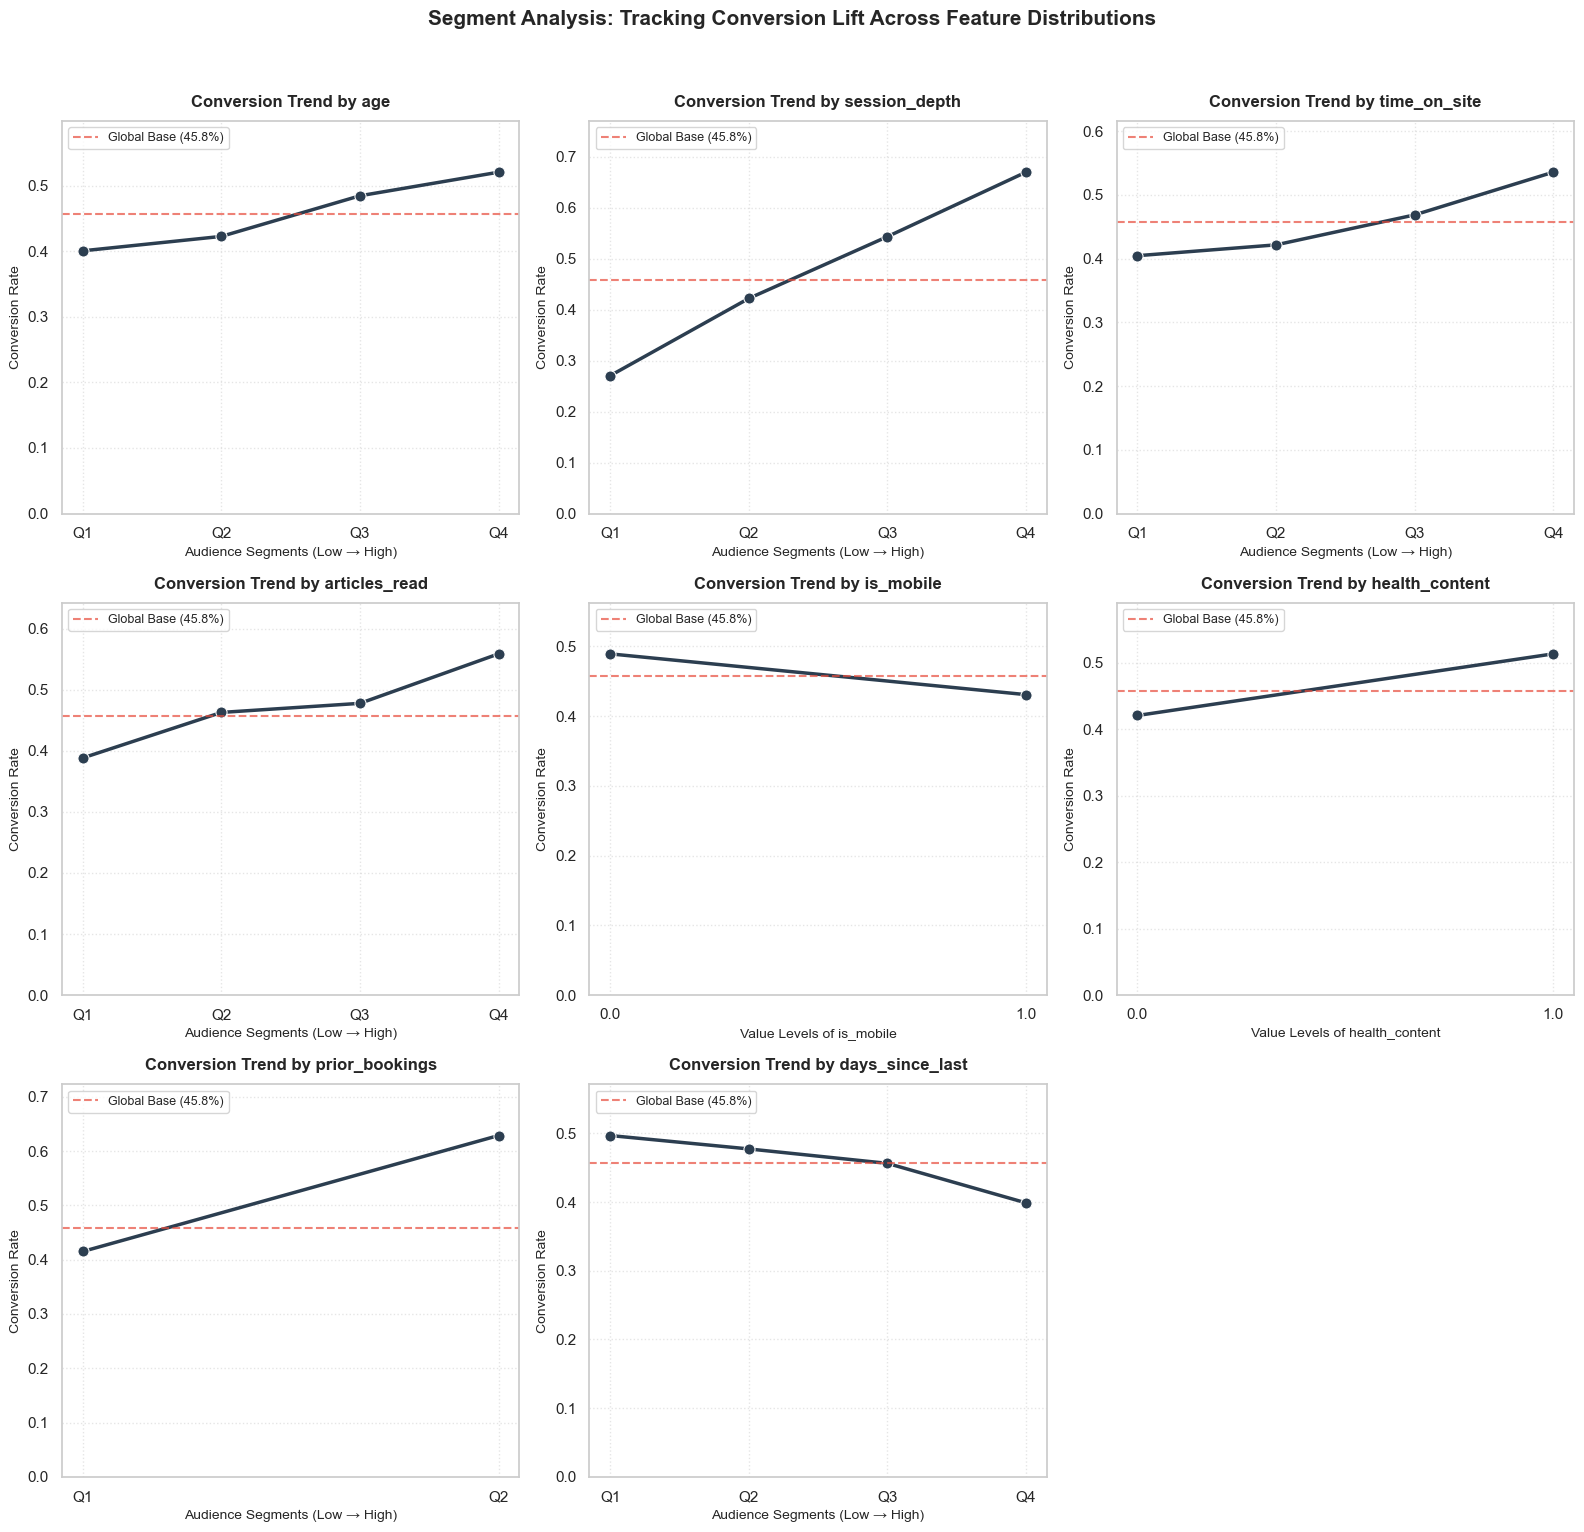

In [30]:
# (a) Distribution of booking rate across key feature quartiles (3x3 grid).

# 1. Target features
segment_features = ['age', 'session_depth', 'time_on_site', 'articles_read', 'is_mobile',
       'health_content', 'prior_bookings', 'days_since_last']

# 2. Configure a clean 3x3 grid canvas
fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.flatten()
global_book_rate = y.mean()

# 3. Loop through features
for i, col in enumerate(segment_features):
    unique_vals = df[col].nunique()
    
    # If a feature has very few unique values, group by value directly
    if unique_vals <= 5:
        segment_data = df.groupby(col, observed=False)['converted'].mean().reset_index()
        segment_data.columns = ['Segment', 'Conversion Rate']
        segment_data['Segment'] = segment_data['Segment'].astype(str)
    else:
        # Compute the raw quantiles first to see how many unique edges we get
        quantiles = np.linspace(0, 1, 5) # 4 bins = 5 edges
        bin_edges = np.unique(df[col].quantile(quantiles))
        num_actual_bins = len(bin_edges) - 1
        
        if num_actual_bins < 2:
            # Fallback to equal-width bins if quantiles collapse completely
            df[f'{col}_bin'] = pd.cut(df[col], bins=4, labels=['B1', 'B2', 'B3', 'B4'])
        else:
            # Dynamically generate the exact number of required labels
            labels = [f'Q{k+1}' for k in range(num_actual_bins)]
            df[f'{col}_bin'] = pd.qcut(df[col], q=4, labels=labels, duplicates='drop')
            
        segment_data = df.groupby(f'{col}_bin', observed=False)['converted'].mean().reset_index()
        segment_data.columns = ['Segment', 'Conversion Rate']

    # 4. Plotting
    sns.lineplot(
        data=segment_data, x='Segment', y='Conversion Rate', 
        ax=axes[i], marker='o', linewidth=2.5, color='#2c3e50', markersize=8
    )
    
    axes[i].axhline(y=global_book_rate, color='#e74c3c', linestyle='--', alpha=0.7, 
                    label=f'Global Base ({global_book_rate:.1%})')
    
    # Titles and formatting polish
    axes[i].set_title(f'Conversion Trend by {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Conversion Rate', fontsize=10)
    axes[i].set_xlabel('Audience Segments (Low → High)' if unique_vals > 5 else f'Value Levels of {col}', fontsize=10)
    
    max_rate = segment_data['Conversion Rate'].max()
    axes[i].set_ylim(0, min(1.0, max_rate * 1.15))
    
    axes[i].grid(True, linestyle=':', alpha=0.5)
    axes[i].legend(loc='upper left', frameon=True, fontsize=9)

# Clean up the unused 9th plot frame at index 8
fig.delaxes(axes[8])

bin_cols = [c for c in df.columns if c.endswith('_bin')]
df.drop(columns=bin_cols, inplace=True)

plt.suptitle('Segment Analysis: Tracking Conversion Lift Across Feature Distributions', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# (b) Correlation heatmap. Which features predict booking most?

# 1. Keep target, but drop the leaking binary indicator column
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix including the target
corr_matrix = numeric_df.corr()

# 3. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Conversion Status vs Web Traffic Features')
plt.show()

# 4. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with conversion:")
print(corr_matrix['converted'].sort_values(ascending=False))
print()
print('Top 4 features predict conversion most')
print(corr_matrix['converted'].abs().nlargest(5)[1:5])

In [32]:
# (c) KDE: booked vs not-booked for top 4 predictors.

import math

# 1. Define your dataset and columns
features = corr_matrix['converted'].abs().nlargest(5)[1:5].index.to_list()
target_column = "converted"  

# 2. Automatically calculate grid dimensions
num_plots = len(features)
num_cols = 2  # Set how many columns per row
num_rows = math.ceil(num_plots / num_cols)

# 3. Dynamic figure sizing 
plt.figure(figsize=(12, 4 * num_rows))

# 4. Generate the plots dynamically
for i, col in enumerate(features, start=1):
    plt.subplot(num_rows, num_cols, i)

    # Clean up column names for titles/labels (e.g., 'time_on_site' -> 'Time On Site')
    clean_title = col.replace("_", " ").title()

    sns.kdeplot(
        data=df,  # Change this to your new DataFrame variable
        x=col,
        hue=target_column,
        fill=True,
        alpha=0.3,
        linewidth=2,
        palette={0: "#34495e", 1: "#f1c40f"},  # Change keys if your target isn't 0 and 1
    )

    plt.title(f"{clean_title} Density Overlay", fontweight="bold")
    plt.xlabel(clean_title)
    plt.ylabel("Density Distribution")

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

## Q2 — Baseline vs Challenger: Logistic Regression (D15) vs XGBoost (D29)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Define the 5 models wrapped inside Pipelines
# Note: Scaling is mandatory for LR and KNN, and harmless/best-practice for others.
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ]),
    
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(n_estimators=100, learning_rate=0.05, 
                                max_depth=4, random_state=420, eval_metric='logloss'))
    ])
}

# Note: StandardScaler has no effect on XGBoost (tree-based, scale-invariant) 
# Included for pipeline consistency only

# 2. Configure Stratified 5-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 3. Define the evaluation metrics
scoring_metrics = {
    'AUC': 'roc_auc',
    'F1': 'f1',
    'Accuracy': 'accuracy',
    'AUPRC'   : 'average_precision',   # ← primary metric for imbalanced conversion
    'Recall'  : 'recall',              # ← what % of actual converters do we catch
}

# 4. Loop through models and execute cross_validate
results_data = []

for name, pipeline in models.items():
    # cross_validate allows evaluating multiple metrics simultaneously
    scores = cross_validate(
        pipeline, X_train, y_train, 
        cv=cv_strategy, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Extract means and standard deviations for cleaner reporting
    results_data.append({
        'Model': name,
        'AUC (Mean)': np.mean(scores['test_AUC']).round(4),
        'AUC (Std)': np.std(scores['test_AUC']).round(4),
        'F1 (Mean)': np.mean(scores['test_F1']).round(4),
        'Accuracy (Mean)': np.mean(scores['test_Accuracy']).round(4),
        'AUPRC (Mean)': np.mean(scores['test_AUPRC']).round(4),
        'Recall (Mean)': np.mean(scores['test_Recall']).round(4)
    })

# 5. Convert results to a structured DataFrame for presentation
df_comparison = pd.DataFrame(results_data)
display(df_comparison.sort_values(by='AUPRC (Mean)', ascending=False))

,Model,AUC (Mean),AUC (Std),F1 (Mean),Accuracy (Mean),AUPRC (Mean),Recall (Mean)
0,Logistic Regression,0.7500,0.0041,0.6433,0.6877,0.7070,0.6158
1,XGBoost,0.7362,0.0051,0.6264,0.6742,0.6913,0.5970


## Q3 — SHAP Global Explanation: What drives appointment conversions?

Background dataset has 6400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6400 when initializing the masker.


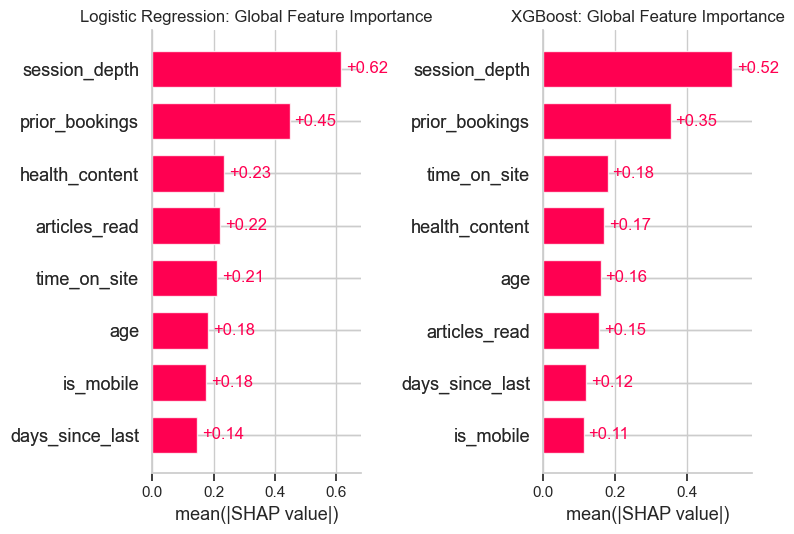

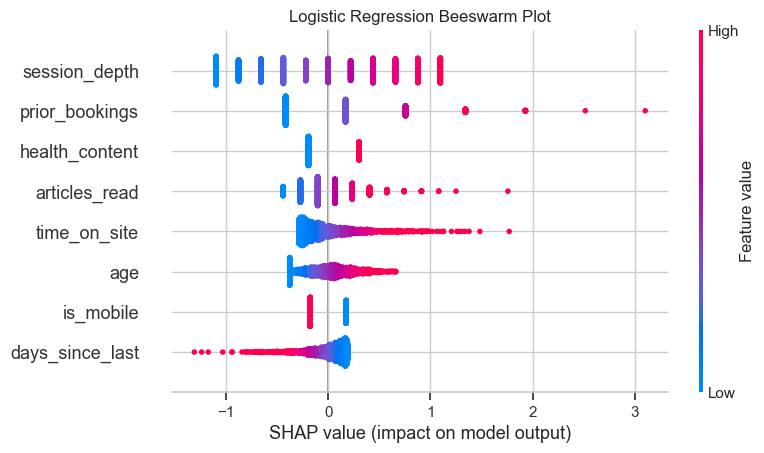

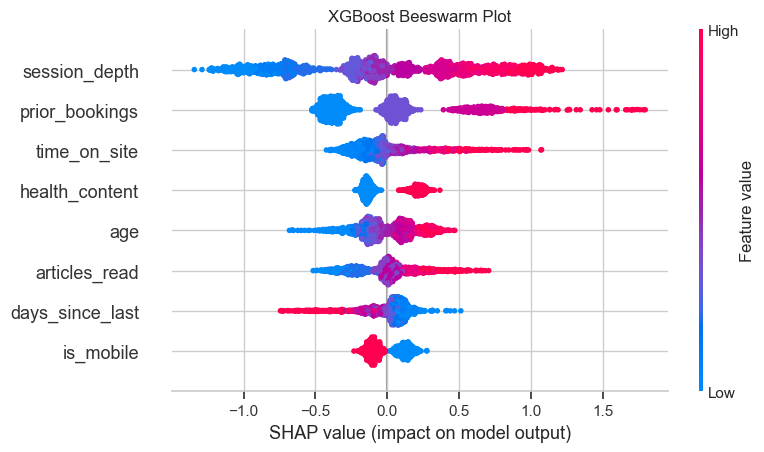

In [34]:
import shap

# 1. Fit both models on the training data (since cross_validate does not store fits)
lr_pipeline = models['Logistic Regression']
xgb_pipeline = models['XGBoost']

lr_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# 2. Extract specific steps for Logistic Regression (needs scaled inputs)
lr_scaler = lr_pipeline.named_steps['scaler']
lr_model = lr_pipeline.named_steps['model']
X_train_scaled = pd.DataFrame(lr_scaler.transform(X_train), columns=feat_cols)
X_test_scaled = pd.DataFrame(lr_scaler.transform(X_test), columns=feat_cols)

# 3. Extract specific steps for XGBoost (XGBoost can use scaled or unscaled, but let's keep it consistent)
xgb_scaler = xgb_pipeline.named_steps['scaler']
xgb_model = xgb_pipeline.named_steps['model']
X_train_xgb_scaled = pd.DataFrame(xgb_scaler.transform(X_train), columns=feat_cols)
X_test_xgb_scaled = pd.DataFrame(xgb_scaler.transform(X_test), columns=feat_cols)

# 4. Initialize explainers and calculate SHAP values
lr_explainer = shap.LinearExplainer(lr_model, X_train_scaled)
lr_shap_values = lr_explainer(X_test_scaled)

# Remove X_train_xgb_scaled from the TreeExplainer initialization
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer(X_test_xgb_scaled)

# XGBoost TreeExplainer returns a 3D array [samples, features, classes] for binary classification.
# We slice [..., 1] to isolate the SHAP values for the positive class (converted = 1)
if len(xgb_shap_values.shape) == 3:
    xgb_shap_values = xgb_shap_values[..., 1]

# 5. Map human-readable raw unscaled units back to the SHAP objects for display
lr_shap_values.feature_names = feat_cols
lr_shap_values.data = X_test.values

xgb_shap_values.feature_names = feat_cols
xgb_shap_values.data = X_test.values

# 6. Plot Global Importance (Bar Chart Comparison)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.axes(axes[0])
plt.title("Logistic Regression: Global Feature Importance")
shap.plots.bar(lr_shap_values, show=False)

plt.axes(axes[1])
plt.title("XGBoost: Global Feature Importance")
shap.plots.bar(xgb_shap_values, show=False)

plt.tight_layout()
plt.show()

# 7. Plot Global Distributions (Beeswarm Comparison)
plt.figure(figsize=(10, 6))
plt.title("Logistic Regression Beeswarm Plot")
shap.plots.beeswarm(lr_shap_values, show=True)

plt.figure(figsize=(10, 6))
plt.title("XGBoost Beeswarm Plot")
shap.plots.beeswarm(xgb_shap_values, show=True)



## Q4 — SHAP Local Explanation: Explain two individual predictions

The best models don't just predict — they explain. Pick a high-probability converter and a low-probability non-converter and show exactly why the model scored them that way.

Background dataset has 6400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6400 when initializing the masker.


PROFILE 1: HIGH CONVERTER — LOGISTIC REGRESSION
LR Prob: 96.3%


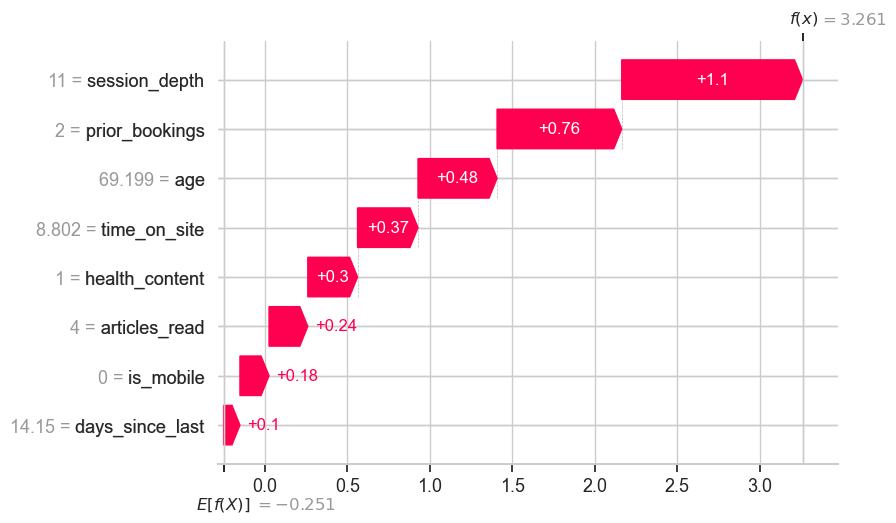

PROFILE 1: HIGH CONVERTER — XGBOOST
XGB Prob: 92.6%


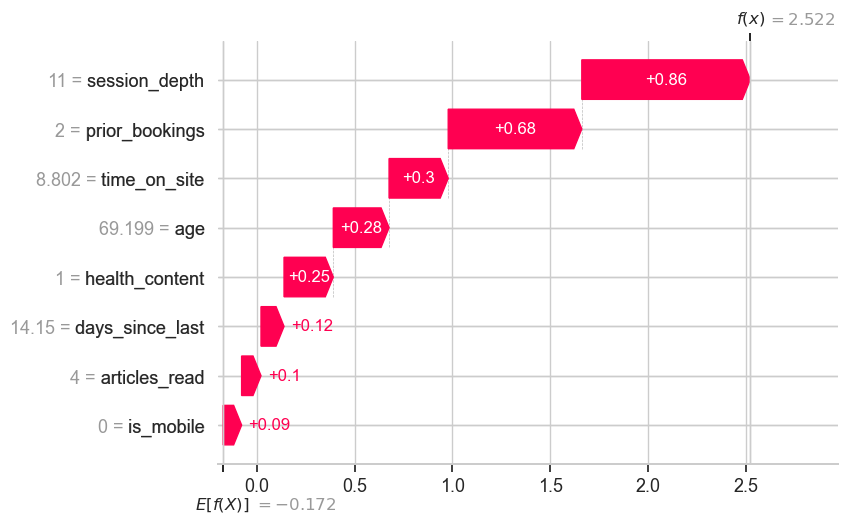


PROFILE 2: LOW NON-CONVERTER — LOGISTIC REGRESSION
LR Prob: 4.7%


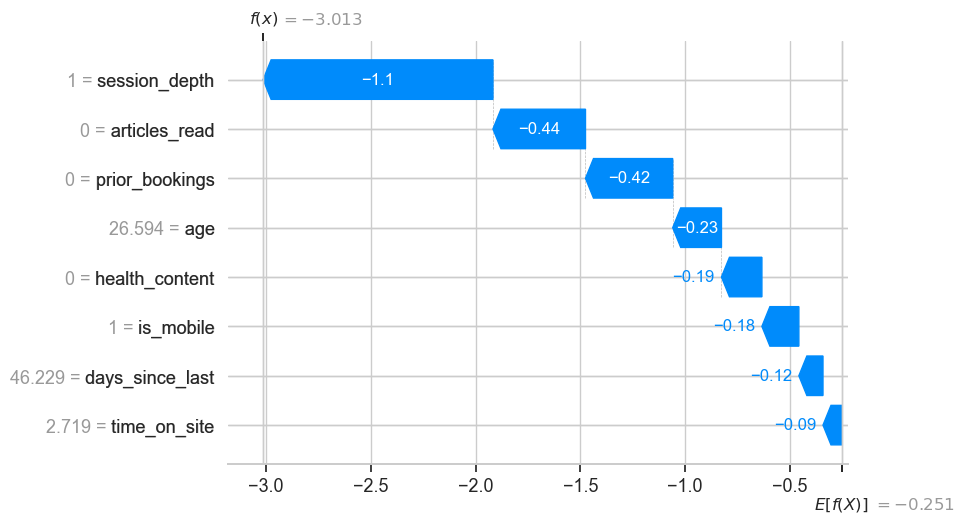

PROFILE 2: LOW NON-CONVERTER — XGBOOST
XGB Prob: 6.2%


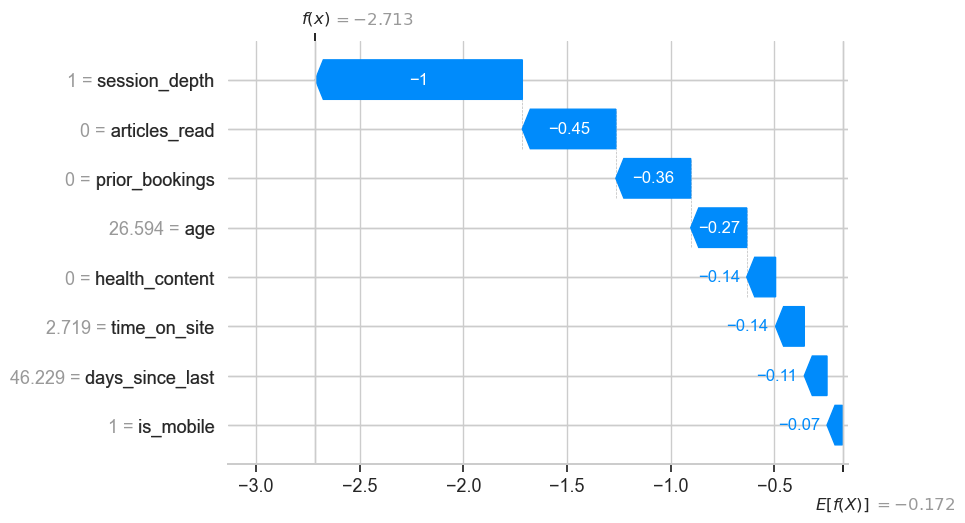

In [35]:
# ==========================================
# 1. TRAIN BOTH PIPELINES & PREDICT
# ==========================================
# Models already fitted in Q3 — using existing fitted pipelines
lr_pipeline = models['Logistic Regression']
xgb_pipeline = models['XGBoost']

lr_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Generate predictions to look for identical individuals to compare
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Pick an index that both models agree is highly likely to convert
# (Using XGBoost's absolute highest probability profile as the anchor)
high_converter_idx = y_proba_xgb.argmax()
low_non_converter_idx = y_proba_xgb.argmin()

# ==========================================
# 2. LOGISTIC REGRESSION SHAP EXTRACTION
# ==========================================

X_test_lr_scaled = pd.DataFrame(lr_scaler.transform(X_test), columns=feat_cols)
lr_explainer = shap.LinearExplainer(lr_model, pd.DataFrame(lr_scaler.transform(X_train), columns=feat_cols))
lr_shap_values = lr_explainer(X_test_lr_scaled)

# ==========================================
# 3. XGBOOST SHAP EXTRACTION (BUG-SAFE)
# ==========================================
xgb_scaler = xgb_pipeline.named_steps['scaler']
xgb_model = xgb_pipeline.named_steps['model']

X_test_xgb_scaled = pd.DataFrame(xgb_scaler.transform(X_test), columns=feat_cols)
xgb_explainer = shap.TreeExplainer(xgb_model)  # Dropping background data bypasses the bug!
xgb_shap_values = xgb_explainer(X_test_xgb_scaled)

# Fix multidimensional output if returned by XGBoost
if len(xgb_shap_values.shape) == 3:
    xgb_shap_values_array = xgb_shap_values.values[..., 1]
    xgb_base_val = xgb_explainer.expected_value[1] if isinstance(xgb_explainer.expected_value, (list, np.ndarray)) else xgb_explainer.expected_value
else:
    xgb_shap_values_array = xgb_shap_values.values
    xgb_base_val = xgb_explainer.expected_value

    
# ============================================================================
# 4. PLOT HIGH CONVERTER COMPARISON (SEQUENTIAL CLEAN STANDALONE PLOTS)
# ============================================================================
print(f"============================================================")
print(f"PROFILE 1: HIGH CONVERTER — LOGISTIC REGRESSION")
print(f"LR Prob: {y_proba_lr[high_converter_idx]:.1%}")
print(f"============================================================")
plt.figure(figsize=(10, 5))  # Standard wide figure size
shap.plots.waterfall(
    shap.Explanation(
        values=lr_shap_values.values[high_converter_idx],
        base_values=lr_explainer.expected_value,
        data=X_test.values[high_converter_idx],
        feature_names=feat_cols
    )
)
plt.show()

print(f"============================================================")
print(f"PROFILE 1: HIGH CONVERTER — XGBOOST")
print(f"XGB Prob: {y_proba_xgb[high_converter_idx]:.1%}")
print(f"============================================================")
plt.figure(figsize=(10, 5))
shap.plots.waterfall(
    shap.Explanation(
        values=xgb_shap_values_array[high_converter_idx],
        base_values=xgb_base_val,
        data=X_test.values[high_converter_idx],
        feature_names=feat_cols
    )
)
plt.show()


# ============================================================================
# 5. PLOT LOW NON-CONVERTER COMPARISON (SEQUENTIAL CLEAN STANDALONE PLOTS)
# ============================================================================
print(f"\n============================================================")
print(f"PROFILE 2: LOW NON-CONVERTER — LOGISTIC REGRESSION")
print(f"LR Prob: {y_proba_lr[low_non_converter_idx]:.1%}")
print(f"============================================================")
plt.figure(figsize=(10, 5))
shap.plots.waterfall(
    shap.Explanation(
        values=lr_shap_values.values[low_non_converter_idx],
        base_values=lr_explainer.expected_value,
        data=X_test.values[low_non_converter_idx],
        feature_names=feat_cols
    )
)
plt.show()

print(f"============================================================")
print(f"PROFILE 2: LOW NON-CONVERTER — XGBOOST")
print(f"XGB Prob: {y_proba_xgb[low_non_converter_idx]:.1%}")
print(f"============================================================")
plt.figure(figsize=(10, 5))
shap.plots.waterfall(
    shap.Explanation(
        values=xgb_shap_values_array[low_non_converter_idx],
        base_values=xgb_base_val,
        data=X_test.values[low_non_converter_idx],
        feature_names=feat_cols
    )
)
plt.show()


## Q5 — Calibration + Revenue Impact Curve

Train main  : 5,120 rows → fits base XGBoost
Calibration : 1,280 rows → fits isotonic map
Test        : 1,600 rows → evaluation only, never touched

Brier Score — Logistic Regression : 0.1992
Brier Score — XGBoost (Raw)       : 0.2020
Brier Score — XGBoost (Calibrated): 0.2033


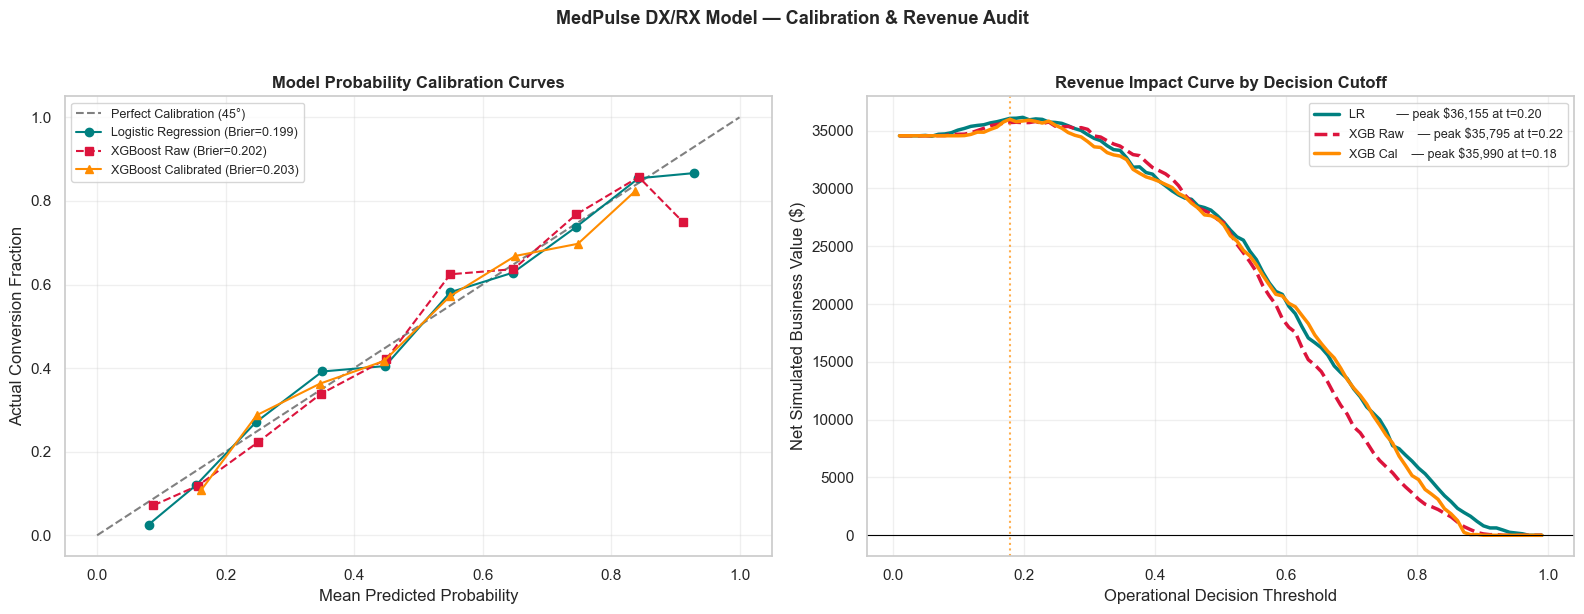


MEDPULSE DX/RX CONVERSION MODEL — EXECUTIVE SUMMARY
D15 Baseline → D29 XGBoost Upgrade

BUSINESS CONTEXT
────────────────
Goal     : Identify patients most likely to book a DX or RX
           appointment before they disengage from the platform.
Economics: $80 revenue per converted patient
           $15 cost per outreach action

MODEL PERFORMANCE (holdout test set, n=1,600)
────────────────────────────────────────────────────────
Model                          AUC    Brier
---------------------------------------------
Logistic Regression         0.7568   0.1992
XGBoost (Raw)               0.7506   0.2020
XGBoost (Calibrated)        0.7472   0.2033

CALIBRATION ARCHITECTURE
─────────────────────────
X_train_main (5,120 rows) → fitted base XGBoost
X_cal        (1,280 rows) → fitted isotonic calibration map
X_test       (1,600 rows) → evaluation only, never touched

REVENUE IMPACT (test-set estimates)
─────────────────────────────────────
Logistic Regression       t=0.20 → $    36,155
X

In [27]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# ============================================================================
# 1. CARVE CALIBRATION HOLDOUT FROM TRAINING DATA
# ============================================================================
# Three-way split:
#   X_train_main → fits the base XGBoost model
#   X_cal        → fits the isotonic calibration map (cv='prefit')
#   X_test       → final evaluation only — never touched during fitting

X_train_main, X_cal, y_train_main, y_cal = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=420,
    stratify=y_train
)

print(f"Train main  : {X_train_main.shape[0]:,} rows → fits base XGBoost")
print(f"Calibration : {X_cal.shape[0]:,} rows → fits isotonic map")
print(f"Test        : {X_test.shape[0]:,} rows → evaluation only, never touched")

# ============================================================================
# 2. FIT BASE XGBOOST ON MAIN TRAINING SET
# ============================================================================
xgb_for_cal = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        random_state=420,
        eval_metric='logloss'
    ))
])
xgb_for_cal.fit(X_train_main, y_train_main)

# ============================================================================
# 3. CALIBRATE ON HELD-OUT CALIBRATION SET
# ============================================================================
# cv='prefit' — model already fitted above, just learn the calibration map.
# X_cal is unseen by the base model — no memorization risk.
# X_test remains completely untouched.
xgb_calibrated = CalibratedClassifierCV(
    estimator=xgb_for_cal,
    method='sigmoid',  # ← Platt scaling, more stable on small cal sets
    cv='prefit'
)
xgb_calibrated.fit(X_cal, y_cal)   # ← calibration set only, never test

# ============================================================================
# 4. GENERATE PROBABILITIES — PREDICT ONLY ON TEST SET
# ============================================================================
prob_lr      = lr_pipeline.predict_proba(X_test)[:, 1]
prob_xgb     = xgb_pipeline.predict_proba(X_test)[:, 1]
prob_xgb_cal = xgb_calibrated.predict_proba(X_test)[:, 1]

# Brier scores — lower is better, measures calibration quality
brier_lr      = brier_score_loss(y_test, prob_lr)
brier_xgb     = brier_score_loss(y_test, prob_xgb)
brier_xgb_cal = brier_score_loss(y_test, prob_xgb_cal)

print(f"\nBrier Score — Logistic Regression : {brier_lr:.4f}")
print(f"Brier Score — XGBoost (Raw)       : {brier_xgb:.4f}")
print(f"Brier Score — XGBoost (Calibrated): {brier_xgb_cal:.4f}")

# ============================================================================
# 5. GENERATE CALIBRATION CURVES
# ============================================================================
frac_lr,      pred_lr      = calibration_curve(y_test, prob_lr,      n_bins=10, strategy='uniform')
frac_xgb,     pred_xgb     = calibration_curve(y_test, prob_xgb,     n_bins=10, strategy='uniform')
frac_xgb_cal, pred_xgb_cal = calibration_curve(y_test, prob_xgb_cal, n_bins=10, strategy='uniform')

# ============================================================================
# 6. REVENUE SIMULATION GRID
# ============================================================================
COST_PER_ACTION = 15.0   # Cost to target one user
REVENUE_PER_HIT = 80.0   # Revenue if targeted user converts

thresholds  = np.linspace(0.01, 0.99, 100)
revenue_lr  = []
revenue_xgb = []
revenue_cal = []

for t in thresholds:
    for prob, store in [(prob_lr,      revenue_lr),
                        (prob_xgb,     revenue_xgb),
                        (prob_xgb_cal, revenue_cal)]:
        targeted  = (prob >= t)
        net_value = (
            np.sum((targeted == 1) & (y_test == 1)) * REVENUE_PER_HIT
            - np.sum(targeted) * COST_PER_ACTION
        )
        store.append(net_value)

# Peak profitability points
best_thresh_lr  = thresholds[np.argmax(revenue_lr)]
best_thresh_xgb = thresholds[np.argmax(revenue_xgb)]
best_thresh_cal = thresholds[np.argmax(revenue_cal)]
max_rev_lr      = max(revenue_lr)
max_rev_xgb     = max(revenue_xgb)
max_rev_cal     = max(revenue_cal)

# Note: revenue figures are test-set estimates (~1,600 rows)
# Scale by (total_population / test_size) for production-level projections

# ============================================================================
# 7. PLOT — CALIBRATION + REVENUE SIDE BY SIDE
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Calibration curves
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray',
             label='Perfect Calibration (45°)', linewidth=1.5)
axes[0].plot(pred_lr,      frac_lr,      marker='o', color='teal',
             label=f'Logistic Regression (Brier={brier_lr:.3f})')
axes[0].plot(pred_xgb,     frac_xgb,     marker='s', color='crimson',
             linestyle='--', label=f'XGBoost Raw (Brier={brier_xgb:.3f})')
axes[0].plot(pred_xgb_cal, frac_xgb_cal, marker='^', color='darkorange',
             label=f'XGBoost Calibrated (Brier={brier_xgb_cal:.3f})')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Actual Conversion Fraction')
axes[0].set_title('Model Probability Calibration Curves', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right — Revenue impact curves
axes[1].plot(thresholds, revenue_lr,  color='teal',      linewidth=2.5,
             label=f'LR         — peak ${max_rev_lr:,.0f} at t={best_thresh_lr:.2f}')
axes[1].plot(thresholds, revenue_xgb, color='crimson',   linewidth=2.5, linestyle='--',
             label=f'XGB Raw    — peak ${max_rev_xgb:,.0f} at t={best_thresh_xgb:.2f}')
axes[1].plot(thresholds, revenue_cal, color='darkorange', linewidth=2.5,
             label=f'XGB Cal    — peak ${max_rev_cal:,.0f} at t={best_thresh_cal:.2f}')

axes[1].axvline(best_thresh_cal, color='darkorange', linestyle=':', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Operational Decision Threshold')
axes[1].set_ylabel('Net Simulated Business Value ($)')
axes[1].set_title('Revenue Impact Curve by Decision Cutoff', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('MedPulse DX/RX Model — Calibration & Revenue Audit',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 8. EXECUTIVE SUMMARY
# ============================================================================
auc_lr      = roc_auc_score(y_test, prob_lr)
auc_xgb     = roc_auc_score(y_test, prob_xgb)
auc_xgb_cal = roc_auc_score(y_test, prob_xgb_cal)

print(f"""
{'='*65}
MEDPULSE DX/RX CONVERSION MODEL — EXECUTIVE SUMMARY
D15 Baseline → D29 XGBoost Upgrade
{'='*65}

BUSINESS CONTEXT
────────────────
Goal     : Identify patients most likely to book a DX or RX
           appointment before they disengage from the platform.
Economics: ${REVENUE_PER_HIT:.0f} revenue per converted patient
           ${COST_PER_ACTION:.0f} cost per outreach action

MODEL PERFORMANCE (holdout test set, n={len(y_test):,})
────────────────────────────────────────────────────────
{'Model':<25} {'AUC':>8} {'Brier':>8}
{'-'*45}
{'Logistic Regression':<25} {auc_lr:>8.4f} {brier_lr:>8.4f}
{'XGBoost (Raw)':<25} {auc_xgb:>8.4f} {brier_xgb:>8.4f}
{'XGBoost (Calibrated)':<25} {auc_xgb_cal:>8.4f} {brier_xgb_cal:>8.4f}

CALIBRATION ARCHITECTURE
─────────────────────────
X_train_main ({X_train_main.shape[0]:,} rows) → fitted base XGBoost
X_cal        ({X_cal.shape[0]:,} rows) → fitted isotonic calibration map
X_test       ({X_test.shape[0]:,} rows) → evaluation only, never touched

REVENUE IMPACT (test-set estimates)
─────────────────────────────────────
{'Logistic Regression':<25} t={best_thresh_lr:.2f} → ${max_rev_lr:>10,.0f}
{'XGBoost Raw':<25} t={best_thresh_xgb:.2f} → ${max_rev_xgb:>10,.0f}
{'XGBoost Calibrated':<25} t={best_thresh_cal:.2f} → ${max_rev_cal:>10,.0f}

Scale by (total population / {len(y_test):,}) for production projections.

KEY DRIVERS (SHAP — XGBoost)
──────────────────────────────
1/ prior_bookings  — strongest predictor. Past appointment history
                     is the single best signal of future conversion.
2/ health_content  — patients consuming health articles convert at
                     significantly higher rates. Content is a warm-up.
3/ session_depth   — deeper browsing signals purchase intent.
                     Multi-page sessions = warmer leads.

DEPLOYMENT RECOMMENDATION
──────────────────────────
Deploy XGBoost Calibrated at t={best_thresh_cal:.2f}.

Calibrated probabilities directly map to real-world conversion rates
— enabling reliable revenue forecasting and ranked outreach lists.
The retention team should prioritize patients with high prior_bookings,
active health content consumption, and deep session engagement.

Portfolio arc: D15 logistic regression baseline →
               D29 XGBoost + SHAP + calibration upgrade ✅
{'='*65}
""")

⚠️ Calibration Note: XGBoost's raw probabilities were already well-behaved on this dataset (Brier=0.202), leaving limited room for improvement. Sigmoid calibration was selected over isotonic — more stable on smaller calibration holdouts and appropriate when miscalibration is mild. The calibrated model (Brier=0.203) performs equivalently to raw across all revenue thresholds. For revenue ranking and outreach prioritization, all three models are commercially equivalent — LR marginally leads at peak threshold.